# CIK Threshold Tuning

Start from the per-CIK profile built in `cik_behavior_analysis.ipynb` (loaded from the same `cache/` parquets), pin the population to a sensible portfolio-size band, then derive p20–p80 thresholds for the remaining filter parameters.

**Default population filters (locked):**
- `min_quarters = 8`
- `min_n_holdings = 10`
- `max_n_holdings = 200`

**Tuning rule:** for each remaining metric, drop outliers below p20 and above p80. The interior 60% becomes the recommended `min_*` / `max_*` range.

The notebook is read-only against the cache — it does not touch `cik_behavior_analysis.ipynb` or hit the DB.

## Setup — load cached parquets and rebuild the profile

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

def project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "ETL").is_dir():
            return p
    raise FileNotFoundError(f"could not locate project root from {cwd}")

ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

def find_cache_dir() -> Path:
    sentinel = "quarter_stats.parquet"
    here = Path.cwd().resolve()
    for c in [here / "cache", here.parent / "cache",
              ROOT / "SocialNetwork" / "src" / "Korkevados" / "cache",
              ROOT / "cache"]:
        if (c / sentinel).exists():
            return c.resolve()
    raise FileNotFoundError(
        "cache parquets not found — run the cik_behavior_analysis.ipynb "
        "setup cell first to populate cache/")

CACHE = find_cache_dir()
print("cache dir:", CACHE)

qstats_pq   = CACHE / "quarter_stats.parquet"
aum_pq      = CACHE / "aum.parquet"
churn_pq    = CACHE / "churn.parquet"
duration_pq = CACHE / "duration.parquet"

quarter_stats = (
    pl.scan_parquet(qstats_pq)
      .with_columns((pl.col("year") * 4 + (pl.col("quarter") - 1)).alias("period"))
      .join(
          pl.scan_parquet(aum_pq)
            .with_columns((pl.col("year") * 4 + (pl.col("quarter") - 1)).alias("period"))
            .select("cik", "period", "aum"),
          on=["cik", "period"], how="left",
      )
      .collect()
).to_pandas()
churn    = pl.read_parquet(churn_pq).to_pandas()
duration = pl.read_parquet(duration_pq).to_pandas().set_index("cik")["avg_holding_duration"]

def build_cik_profile(qstats, ch, dur):
    base = qstats.groupby("cik").agg(
        n_quarters=("period", "nunique"),
        first_period=("period", "min"),
        last_period=("period", "max"),
        aum_mean=("aum", "mean"),
        aum_median=("aum", "median"),
        n_holdings_mean=("n_holdings", "mean"),
        n_holdings_std=("n_holdings", "std"),
        hhi_mean=("hhi", "mean"),
        top5_weight_mean=("top5_weight", "mean"),
    )
    aum_sorted = qstats.dropna(subset=["aum"]).sort_values(["cik", "period"]).copy()
    aum_sorted["log_aum"] = np.log(aum_sorted["aum"])
    aum_log_std = aum_sorted.groupby("cik")["log_aum"].std().rename("aum_log_std")
    first_last = aum_sorted.groupby("cik").agg(
        aum_first=("aum", "first"),
        aum_last=("aum", "last"),
        p_first=("period", "first"),
        p_last=("period", "last"),
    )
    dt_years = ((first_last["p_last"] - first_last["p_first"]) / 4).clip(lower=0.25)
    first_last["aum_cagr"] = (first_last["aum_last"] / first_last["aum_first"]) ** (1 / dt_years) - 1
    churn_agg = ch.groupby("cik").agg(
        turnover_mean=("turnover", "mean"),
        turnover_std=("turnover", "std"),
        open_rate_mean=("open_rate", "mean"),
        close_rate_mean=("close_rate", "mean"),
    )
    return base.join(aum_log_std).join(first_last[["aum_cagr"]]).join(churn_agg).join(dur).reset_index()

profile = build_cik_profile(quarter_stats, churn, duration)
print(f"profile rows: {len(profile):,}")
profile.head()

cache dir: C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\SocialNetwork\src\Korkevados\cache
profile rows: 11,408


,cik,n_quarters,first_period,last_period,aum_mean,aum_median,n_holdings_mean,n_holdings_std,hhi_mean,top5_weight_mean,aum_log_std,aum_cagr,turnover_mean,turnover_std,open_rate_mean,close_rate_mean,avg_holding_duration
0,0000002230,46,8055,8101,1.393732e+09,1.248838e+09,109.000000,49.227364,0.023828,0.225421,0.320278,0.098054,0.165876,0.085571,0.138537,0.173481,5.796532
1,0000003520,46,8055,8101,1.867099e+10,1.630120e+10,475.043478,112.135227,0.023670,0.256591,0.319294,0.031395,0.214780,0.079167,0.132299,0.173816,3.873781
2,0000004962,7,8095,8101,9.041537e+08,9.940531e+08,2.000000,0.816497,0.988966,1.000000,2.801543,-0.014467,0.359987,0.472864,0.083333,0.333333,3.500000
3,0000004977,13,8088,8101,1.604378e+08,1.557908e+08,1.692308,0.480384,0.968384,1.000000,0.403836,-0.136323,0.086179,0.183993,0.045455,0.153846,7.333333
4,0000005272,46,8055,8101,3.456824e+10,2.747174e+10,3339.304348,2179.906531,0.183475,0.443992,1.422642,-0.334985,0.186289,0.214413,0.033939,0.085763,2.949746


## Apply default population filters

Lock the population to long-lived filers (`n_quarters >= 8`) whose mean portfolio size sits in the band 10–200 stocks. The remaining tuning is done **within** this group, so the outlier-trim percentiles reflect the population you'll actually train on.

In [6]:
MIN_QUARTERS    = 4
MIN_N_HOLDINGS  = 10
MAX_N_HOLDINGS  = 200

n_before = len(profile)
pop = profile[
    (profile["n_quarters"]       >= MIN_QUARTERS) &
    (profile["n_holdings_mean"]  >= MIN_N_HOLDINGS) &
    (profile["n_holdings_mean"]  <= MAX_N_HOLDINGS)
].copy()

print(f"population: {len(pop):,} CIKs   ({len(pop)/n_before*100:.1f}% of {n_before:,})")
print(f"  filters: min_quarters>={MIN_QUARTERS}, "
      f"n_holdings_mean in [{MIN_N_HOLDINGS}, {MAX_N_HOLDINGS}]")

population: 6,361 CIKs   (55.8% of 11,408)
  filters: min_quarters>=4, n_holdings_mean in [10, 200]


## Compute p20–p80 thresholds for each tuning metric

For every behavioural metric we'd typically clamp via `filter_ciks(...)`, take the **interior 60%** of the population (p20 — p80) and treat those bounds as recommended `min_*` / `max_*` thresholds.

Each plot shows the metric's full distribution with p20 / p80 marked. The table at the bottom is what you'd plug into `filter_ciks()` or `lightGCN.py`.

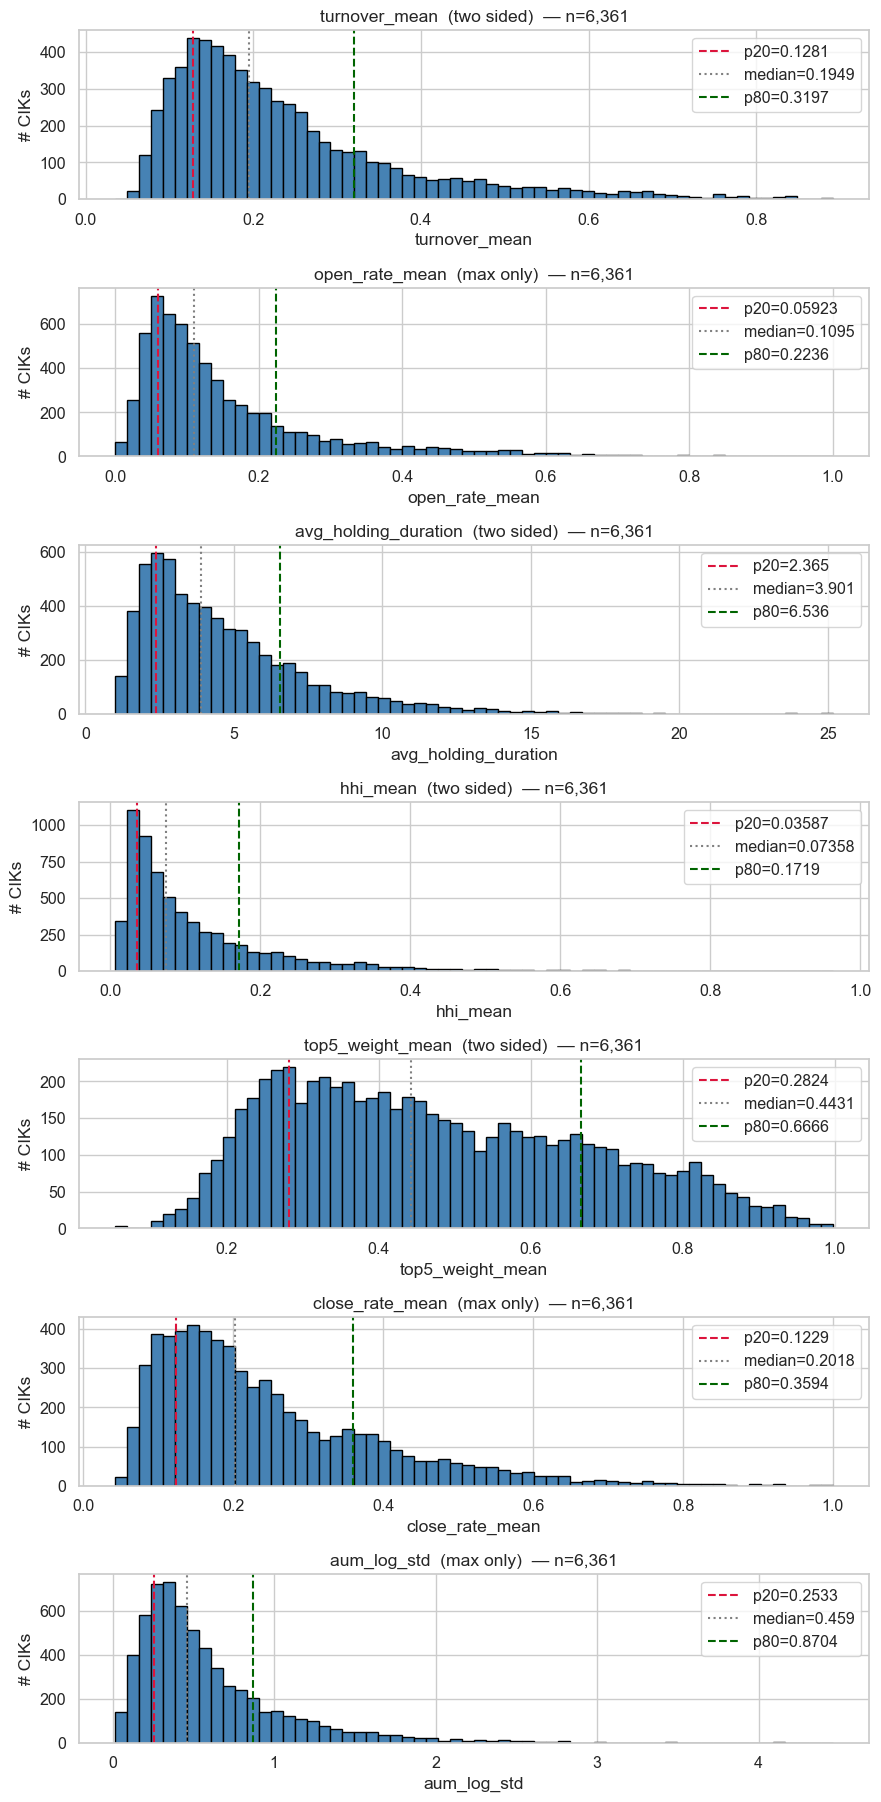


Recommended p20–p80 thresholds (interior 60% of the filtered population):
              metric      kind      p20   median      p80  min_threshold  max_threshold
       turnover_mean two_sided 0.128089 0.194887 0.319711       0.128089       0.319711
      open_rate_mean  max_only 0.059230 0.109486 0.223641            NaN       0.223641
avg_holding_duration two_sided 2.365217 3.901042 6.535529       2.365217       6.535529
            hhi_mean two_sided 0.035870 0.073584 0.171905       0.035870       0.171905
    top5_weight_mean two_sided 0.282423 0.443113 0.666635       0.282423       0.666635
     close_rate_mean  max_only 0.122870 0.201801 0.359351            NaN       0.359351
         aum_log_std  max_only 0.253333 0.458993 0.870405            NaN       0.870405


In [7]:
# Metric → (kind, lightGCN flag stems). kind ∈ {'two_sided','min_only','max_only'}.
TUNE_METRICS = [
    ("turnover_mean",        "two_sided", ("min-turnover",     "max-turnover")),
    ("open_rate_mean",       "max_only",  (None,               "max-open-rate")),
    ("avg_holding_duration", "two_sided", ("min-avg-duration", "max-avg-duration")),
    # The following don't have lightGCN CLI flags yet but are useful in filter_ciks().
    ("hhi_mean",             "two_sided", (None, None)),
    ("top5_weight_mean",     "two_sided", (None, None)),
    ("close_rate_mean",      "max_only",  (None, None)),
    ("aum_log_std",          "max_only",  (None, None)),
]

rows = []
fig, axes = plt.subplots(len(TUNE_METRICS), 1, figsize=(9, 2.6 * len(TUNE_METRICS)))
if len(TUNE_METRICS) == 1:
    axes = [axes]

for ax, (col, kind, _) in zip(axes, TUNE_METRICS):
    s = pop[col].dropna()
    if len(s) == 0:
        ax.set_title(f"{col}: no data"); continue
    p20, p50, p80 = np.quantile(s, [0.20, 0.50, 0.80])
    ax.hist(s, bins=60, color="steelblue", edgecolor="black")
    ax.axvline(p20, color="crimson",  linestyle="--", label=f"p20={p20:.4g}")
    ax.axvline(p50, color="gray",     linestyle=":",  label=f"median={p50:.4g}")
    ax.axvline(p80, color="darkgreen",linestyle="--", label=f"p80={p80:.4g}")
    ax.set_title(f"{col}  ({kind.replace('_', ' ')})  — n={len(s):,}")
    ax.set_xlabel(col); ax.set_ylabel("# CIKs"); ax.legend(loc="upper right")
    rows.append({
        "metric": col, "kind": kind,
        "p20": p20, "median": p50, "p80": p80,
        "min_threshold": p20 if kind in ("two_sided", "min_only") else None,
        "max_threshold": p80 if kind in ("two_sided", "max_only") else None,
    })
plt.tight_layout(); plt.show()

thresholds = pd.DataFrame(rows)
print("\nRecommended p20–p80 thresholds (interior 60% of the filtered population):")
print(thresholds.to_string(index=False))

## Apply the recommended thresholds and see how many CIKs remain

Sanity check: clamping every tuning metric simultaneously is very aggressive (each cut keeps ~60% on its own, but they don't compose multiplicatively because the metrics correlate).

In [8]:
tuned = pop.copy()
mask = pd.Series(True, index=tuned.index)
for _, row in thresholds.iterrows():
    metric = row["metric"]
    if pd.notna(row["min_threshold"]):
        mask &= tuned[metric].fillna(-np.inf) >= row["min_threshold"]
    if pd.notna(row["max_threshold"]):
        mask &= tuned[metric].fillna(np.inf)  <= row["max_threshold"]
tuned_pass = tuned.loc[mask]
print(f"after applying all p20–p80 thresholds: {len(tuned_pass):,} CIKs   "
      f"({len(tuned_pass)/len(pop)*100:.1f}% of the {len(pop):,}-CIK population)")

# Per-metric drop-off (how many CIKs each threshold would remove on its own)
print("\nIndividual cut impact (applied to the population, one at a time):")
for _, row in thresholds.iterrows():
    metric = row["metric"]
    m = pd.Series(True, index=pop.index)
    if pd.notna(row["min_threshold"]):
        m &= pop[metric].fillna(-np.inf) >= row["min_threshold"]
    if pd.notna(row["max_threshold"]):
        m &= pop[metric].fillna(np.inf)  <= row["max_threshold"]
    print(f"  {metric:24s}  keep={m.sum():5,}  drop={(~m).sum():5,}")

after applying all p20–p80 thresholds: 1,240 CIKs   (19.5% of the 6,361-CIK population)

Individual cut impact (applied to the population, one at a time):
  turnover_mean             keep=3,817  drop=2,544
  open_rate_mean            keep=5,089  drop=1,272
  avg_holding_duration      keep=3,817  drop=2,544
  hhi_mean                  keep=3,817  drop=2,544
  top5_weight_mean          keep=3,817  drop=2,544
  close_rate_mean           keep=5,089  drop=1,272
  aum_log_std               keep=5,089  drop=1,272


## Export — ready-to-paste `filter_ciks()` call and `lightGCN.py` CLI args

In [9]:
# Python kwargs for filter_ciks()
py_lines = [
    "filter_ciks(",
    "    profile,",
    f"    min_quarters={MIN_QUARTERS},",
    f"    min_n_holdings={MIN_N_HOLDINGS},",
    f"    max_n_holdings={MAX_N_HOLDINGS},",
]
for _, row in thresholds.iterrows():
    metric = row["metric"]
    if pd.notna(row["min_threshold"]) and metric in (
        "turnover_mean", "avg_holding_duration"):
        kw = "min_turnover" if metric == "turnover_mean" else "min_avg_duration"
        py_lines.append(f"    {kw}={row['min_threshold']:.4g},")
    if pd.notna(row["max_threshold"]) and metric in (
        "turnover_mean", "open_rate_mean", "avg_holding_duration"):
        kw = {"turnover_mean":        "max_turnover",
              "open_rate_mean":       "max_open_rate",
              "avg_holding_duration": "max_avg_duration"}[metric]
        py_lines.append(f"    {kw}={row['max_threshold']:.4g},")
py_lines.append(")")
print("# Python:")
print("\n".join(py_lines))

# lightGCN.py CLI flags
cli = [
    f"--min-n-holdings {MIN_N_HOLDINGS}",
    f"--max-n-holdings {MAX_N_HOLDINGS}",
]
for _, row in thresholds.iterrows():
    metric = row["metric"]; flag_min, flag_max = None, None
    if metric == "turnover_mean":        flag_min, flag_max = "min-turnover", "max-turnover"
    elif metric == "open_rate_mean":     flag_max = "max-open-rate"
    elif metric == "avg_holding_duration": flag_min, flag_max = "min-avg-duration", "max-avg-duration"
    if flag_min and pd.notna(row["min_threshold"]):
        cli.append(f"--{flag_min} {row['min_threshold']:.4g}")
    if flag_max and pd.notna(row["max_threshold"]):
        cli.append(f"--{flag_max} {row['max_threshold']:.4g}")
print("\n# lightGCN.py CLI (note: --min-quarters is not currently a flag; add it if needed):")
print("python lightGCN.py \\\n    " + " \\\n    ".join(cli))

# Python:
filter_ciks(
    profile,
    min_quarters=4,
    min_n_holdings=10,
    max_n_holdings=200,
    min_turnover=0.1281,
    max_turnover=0.3197,
    max_open_rate=0.2236,
    min_avg_duration=2.365,
    max_avg_duration=6.536,
)

# lightGCN.py CLI (note: --min-quarters is not currently a flag; add it if needed):
python lightGCN.py \
    --min-n-holdings 10 \
    --max-n-holdings 200 \
    --min-turnover 0.1281 \
    --max-turnover 0.3197 \
    --max-open-rate 0.2236 \
    --min-avg-duration 2.365 \
    --max-avg-duration 6.536
